# Liquidation-signal datasets — exploratory data analysis

**Goal of this notebook:** build intuition about the four datasets described in `description.md`
(Binance trades / BBO / liquidations + Bybit liquidations, 90 days of `perp:btcusdt` & `perp:ethusdt`)
through pure exploration. No signal is built here — we only look at the data and write down what is there.

The raw trades/BBO files are huge (≈1.1 B trade rows, ≈207 M BBO rows, ~6.5 GB on disk), so heavy
aggregations are done once by `precompute_agg.py` (streaming group-bys) and `precompute_events.py`
(forward-filled BBO mid around events). Both write small tables into `artifacts/`. This notebook loads
those artifacts plus the small liquidation files directly, so it runs in seconds and is fully reproducible.

**Map of the notebook**
1. Inventory & shape — how much data, over what span
2. Time structure — distribution in time, gaps, day/night, burstiness
3. Price context — what the market did over the quarter
4. Distributions — sizes, notionals, spreads, side balance, heavy tails
5. The conventions that bite — timestamp units, `side` meaning, the Bybit +200 ms delay (verified by hand)
6. Cross-source relationships — order book around trades & liquidations, cross-exchange alignment
7. Anomalies / things that look odd
8. Summary of findings

## 0. Setup

In [1]:
import json
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams.update({"figure.figsize": (12, 4.2), "figure.dpi": 110,
                     "axes.grid": True, "grid.alpha": 0.25, "font.size": 10})

# Paths come from the installed package, so the notebook runs from anywhere.
from liqsignal import config
ART = config.ARTIFACTS_DIR
assert ART.exists() and any(ART.glob("*.parquet")), \
    "artifacts/ is empty — run:  make eda"

US = config.US
SYMS = list(config.SYMBOLS)
COL = {"btc": "#f2a900", "eth": "#627eea"}      # bitcoin orange / ethereum blue
SIDE_COL = {"buy": "#1b9e77", "sell": "#d95f02"}

RAW = {(src, sym): config.dataset_path(src, sym)
       for src in ("trades", "bbo", "liq_binance", "liq_bybit")
       for sym in config.SYMBOLS}

def min_to_dt(m):
    # minute-index (since epoch) -> numpy datetime64 for plotting
    return (np.asarray(m, dtype="int64") * 60).astype("datetime64[s]")

def us_to_str(us):
    return datetime.fromtimestamp(us/1e6, tz=timezone.utc).strftime("%Y-%m-%d %H:%M:%S.%f")[:-3]

def load_liq(exch, sym):
    d = pl.read_parquet(RAW[(f"liq_{exch}", sym)])
    return d.with_columns(notional=(pl.col("price")*pl.col("amount")))
print("setup ok — artifacts:", len(list(ART.glob('*.parquet'))), "files")

setup ok — artifacts: 33 files


## 1. Inventory & shape

First, the bird's-eye view: how many rows live in each table, what columns, and what time span they cover.
Counts come from parquet metadata / streaming so nothing large is loaded.

In [2]:
import pyarrow.parquet as pq
rows = []
for (kind, sym), path in RAW.items():
    md_ = pq.read_metadata(path)
    ts_idx = md_.schema.names.index("timestamp")
    gmin = gmax = None
    for rg in range(md_.num_row_groups):
        st = md_.row_group(rg).column(ts_idx).statistics
        gmin = st.min if gmin is None else min(gmin, st.min)
        gmax = st.max if gmax is None else max(gmax, st.max)
    rows.append(dict(table=kind, sym=sym, rows=md_.num_rows,
                     start=us_to_str(gmin)[:19], end=us_to_str(gmax)[:19],
                     span_days=round((gmax-gmin)/1e6/86400, 2),
                     file_MB=round(Path(path).stat().st_size/1e6)))
inv = pd.DataFrame(rows)
inv["rows_per_day"] = (inv["rows"]/inv["span_days"]).round().astype(int)
inv

,table,sym,rows,start,end,span_days,file_MB,rows_per_day
0,trades,btc,401902513,2025-12-01 00:00:00,2026-02-28 23:59:59,90.00,1294,4465583
1,trades,eth,705880385,2025-12-01 00:00:00,2026-02-28 23:59:59,90.00,2119,7843115
2,bbo,btc,99169477,2025-12-01 00:00:02,2026-02-28 23:59:59,90.00,797,1101883
3,bbo,eth,107797036,2025-12-01 00:00:00,2026-02-28 23:59:59,90.00,1249,1197745
4,liq_binance,btc,114255,2025-12-01 00:00:06,2026-02-28 23:59:10,90.00,1,1270
5,liq_binance,eth,131769,2025-12-01 00:00:09,2026-02-28 23:49:50,89.99,2,1464
6,liq_bybit,btc,228655,2025-12-01 00:00:02,2026-02-28 23:58:42,90.00,2,2541
7,liq_bybit,eth,160214,2025-12-01 00:00:07,2026-02-28 23:34:22,89.98,2,1781


**What we see**

* All eight tables cover the **same 90-day window, 2025-12-01 → 2026-02-28 UTC** — train (Dec–Jan) + validation (Feb).
* **Trades dominate**: ETH ≈706 M, BTC ≈402 M rows. **BBO** is ≈100–108 M each. **Liquidations are tiny** (0.1–0.2 M).
* A first surprise: **Bybit reports *more* liquidations than Binance** for both symbols (BTC 229 K vs 114 K; ETH 160 K vs 132 K), despite Bybit being a smaller venue. We will see Bybit also liquidates more *notional*.
* ETH has ~1.75× the trade count of BTC but, as we will see, much smaller notional per trade.

## 2. Time structure — distribution, gaps, day/night, burstiness

### 2.1 Events per day, per source

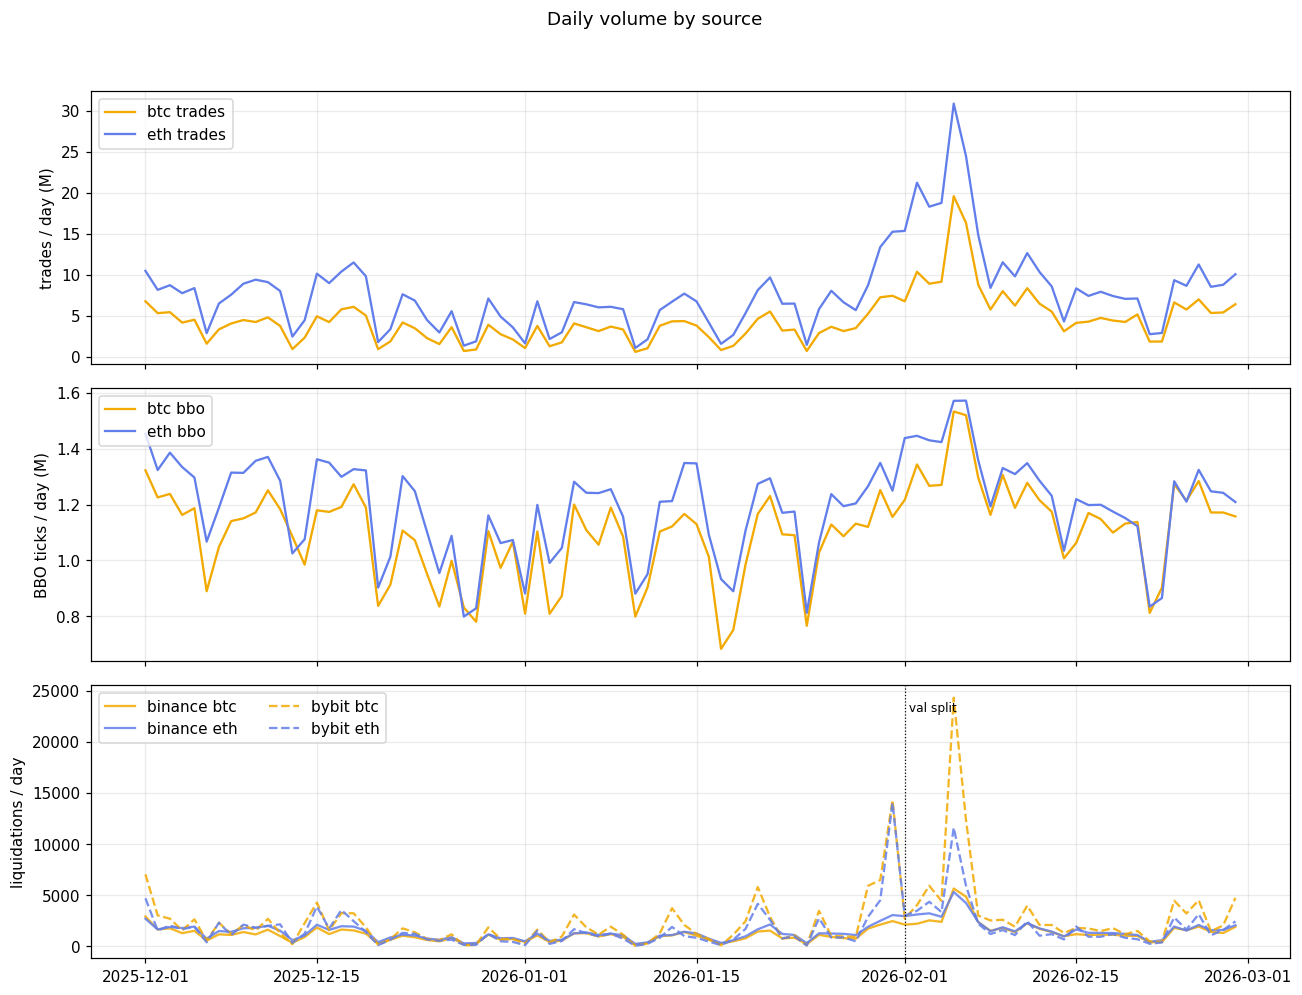

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
# trades & bbo per-day from minute artifacts
for sym in SYMS:
    tm = pl.read_parquet(ART/f"trades_minute_{sym}.parquet").with_columns(day=(pl.col("m")//1440))
    day = tm.group_by("day").agg(n=pl.col("n").sum()).sort("day")
    axes[0].plot(min_to_dt(day["day"]*1440), day["n"]/1e6, color=COL[sym], label=f"{sym} trades")
    bm = pl.read_parquet(ART/f"bbo_minute_{sym}.parquet").with_columns(day=(pl.col("m")//1440))
    bday = bm.group_by("day").agg(n=pl.col("n").sum()).sort("day")
    axes[1].plot(min_to_dt(bday["day"]*1440), bday["n"]/1e6, color=COL[sym], label=f"{sym} bbo")
axes[0].set_ylabel("trades / day (M)"); axes[0].legend(loc="upper left")
axes[1].set_ylabel("BBO ticks / day (M)"); axes[1].legend(loc="upper left")
# liquidations per day, all four feeds
for exch in ["binance", "bybit"]:
    for sym in SYMS:
        d = load_liq(exch, sym).with_columns(day=(pl.col("timestamp")//(86400*US)))
        dd = d.group_by("day").agg(n=pl.len()).sort("day")
        ls = "-" if exch=="binance" else "--"
        axes[2].plot(min_to_dt(dd["day"]*1440), dd["n"], ls, color=COL[sym],
                     label=f"{exch} {sym}", alpha=0.85)
axes[2].set_ylabel("liquidations / day"); axes[2].legend(loc="upper left", ncol=2)
axes[2].axvline(np.datetime64("2026-02-01"), color="k", lw=0.8, ls=":")
axes[2].text(np.datetime64("2026-02-01"), axes[2].get_ylim()[1]*0.9, " val split", fontsize=8)
fig.suptitle("Daily volume by source", y=1.0); plt.tight_layout(rect=[0,0,1,0.97]); plt.show()

* Trade and BBO volume is **fairly stable day-to-day** with clear spikes on volatile days. BBO ticks/day are an order of magnitude below trades — the book-ticker feed is event-throttled (~13 ticks/s), so **trades, not BBO, set the time resolution**.
* Liquidations are **spiky**: most days are quiet, punctuated by cascade days where counts jump 5–20×. Bybit (dashed) sits above Binance (solid) for most days.
* The dotted line marks the train/validation split (Feb 1). Nothing structurally changes there — same regime, same feeds.

### 2.2 Day/night cycle (hour-of-day, UTC)

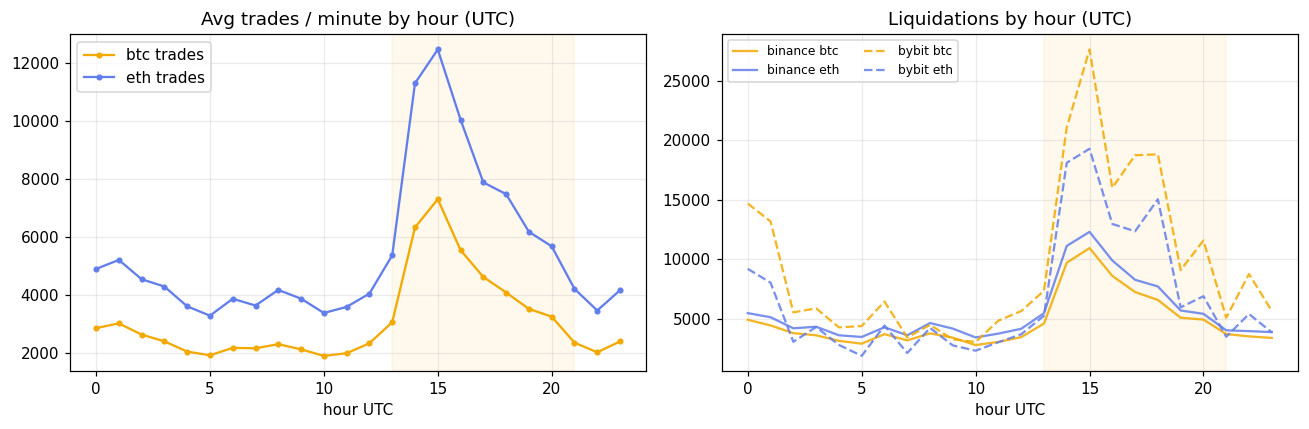

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for sym in SYMS:
    tm = pl.read_parquet(ART/f"trades_minute_{sym}.parquet").with_columns(hr=((pl.col("m")*60)//3600 % 24))
    h = tm.group_by("hr").agg(avg=pl.col("n").mean()).sort("hr")
    axes[0].plot(h["hr"], h["avg"], marker="o", ms=3, color=COL[sym], label=f"{sym} trades")
axes[0].set_title("Avg trades / minute by hour (UTC)"); axes[0].set_xlabel("hour UTC")
axes[0].legend(); axes[0].axvspan(13, 21, color="orange", alpha=0.07)
for exch, ls in [("binance","-"),("bybit","--")]:
    for sym in SYMS:
        d = load_liq(exch, sym).with_columns(hr=((pl.col("timestamp")//(3600*US))%24))
        h = d.group_by("hr").agg(n=pl.len()).sort("hr")
        axes[1].plot(h["hr"], h["n"], ls, color=COL[sym], label=f"{exch} {sym}", alpha=0.85)
axes[1].set_title("Liquidations by hour (UTC)"); axes[1].set_xlabel("hour UTC")
axes[1].legend(ncol=2, fontsize=8); axes[1].axvspan(13, 21, color="orange", alpha=0.07)
plt.tight_layout(); plt.show()

* Strong diurnal cycle. Activity **peaks ~15:00 UTC** (US morning / EU afternoon, shaded band) and **troughs ~05–10:00 UTC** (Asia night). Trade rate swings ~**3.8×** peak-to-trough; Bybit liquidations swing up to **~9×**.
* Liquidations follow the same clock as trades — they cluster in the active, high-volatility hours, not uniformly.

### 2.3 Burstiness and gaps

In [5]:
print("Per-minute trade-count burstiness (90 days = 129,600 minutes):")
for sym in SYMS:
    n = pl.read_parquet(ART/f"trades_minute_{sym}.parquet")["n"]
    print(f"  {sym}: minutes={len(n):,}  min={n.min()}  median={int(n.median())}  "
          f"p99={int(n.quantile(0.99)):,}  max={n.max():,}  (max/median={n.max()/n.median():.0f}x)")

print("\nBBO coverage — missing minutes (shared across symbols => collector/venue outages):")
for sym in SYMS:
    m = pl.read_parquet(ART/f"bbo_minute_{sym}.parquet")
    full = np.arange(m["m"].min(), m["m"].max()+1)
    missing = sorted(set(full) - set(m["m"].to_list()))
    print(f"  {sym}: {len(missing)} missing of {len(full)} ({100*len(missing)/len(full):.3f}%) ->",
          [datetime.fromtimestamp(x*60, tz=timezone.utc).strftime('%m-%d %H:%M') for x in missing])

Per-minute trade-count burstiness (90 days = 129,600 minutes):
  btc: minutes=129,600  min=29  median=1726  p99=21,246  max=127,021  (max/median=74x)
  eth: minutes=129,600  min=58  median=2966  p99=38,124  max=256,896  (max/median=87x)

BBO coverage — missing minutes (shared across symbols => collector/venue outages):
  btc: 6 missing of 129600 (0.005%) -> ['12-22 02:07', '01-29 09:29', '02-03 09:58', '02-26 13:30', '02-26 13:31', '02-26 13:32']
  eth: 9 missing of 129600 (0.007%) -> ['12-22 02:07', '12-22 02:08', '12-22 02:09', '12-22 02:10', '12-22 02:11', '01-29 09:29', '02-03 09:58', '02-03 09:59', '02-26 13:30']


* **Never a dead minute** in trades (min 29 BTC / 58 ETH per minute) — the tape is continuous; the burstiness is entirely volatility-driven (busiest minute is 74–87× the median).
* **BBO is ~99.99% complete**: only 6 (BTC) / 9 (ETH) missing minutes in 90 days, and they fall on the **same wall-clock minutes** for both symbols (e.g. 2025-12-22 02:07, 2026-02-26 13:30–13:32) → these are exchange/collector-wide gaps, not symbol-specific corruption. Worth remembering for forward-fill: a few multi-minute holes exist.

## 3. Price context

What did the market actually do over the quarter? This frames everything else — liquidation skew, volatility clustering, etc.

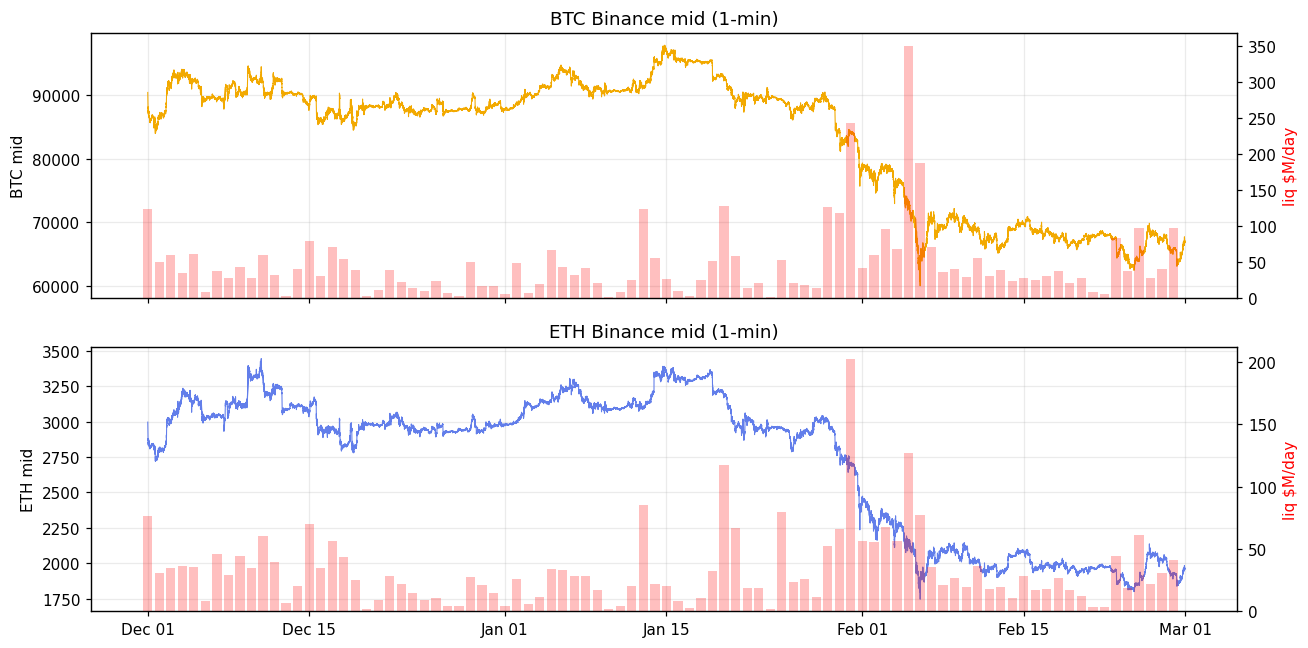

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
for ax, sym in zip(axes, SYMS):
    bm = pl.read_parquet(ART/f"bbo_minute_{sym}.parquet").sort("m")
    t = min_to_dt(bm["m"])
    ax.plot(t, bm["mid_last"], color=COL[sym], lw=0.7)
    ax.set_ylabel(f"{sym.upper()} mid"); ax.set_title(f"{sym.upper()} Binance mid (1-min)")
    # overlay daily total liquidation notional (bybit+binance) as bars on twin axis
    liqn = None
    for exch in ["binance","bybit"]:
        d = load_liq(exch,sym).with_columns(day=(pl.col("timestamp")//(86400*US)))
        dd = d.group_by("day").agg(n=(pl.col("notional")).sum()).sort("day")
        liqn = dd if liqn is None else pl.concat([liqn,dd]).group_by("day").agg(n=pl.col("n").sum()).sort("day")
    ax2 = ax.twinx(); ax2.bar(min_to_dt(liqn["day"]*1440), liqn["n"]/1e6, width=0.8, color="red", alpha=0.25)
    ax2.set_ylabel("liq $M/day", color="red"); ax2.grid(False)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b %d")); plt.tight_layout(); plt.show()

* **BTC fell from ~$90 K (early Dec) to a ~$60 K trough and partially recovered** — a large drawdown quarter; ETH tracks it (3446 → 1736 range). The big red liquidation-notional bars line up with the sharp legs down.
* This explains the **sell-side skew in liquidations** we quantify below: a falling market forces long liquidations (sell-side). It also means any signal must be robust to a trending, not just choppy, regime.

## 4. Distributions

### 4.1 Trade size & notional (heavy tails, BTC vs ETH)

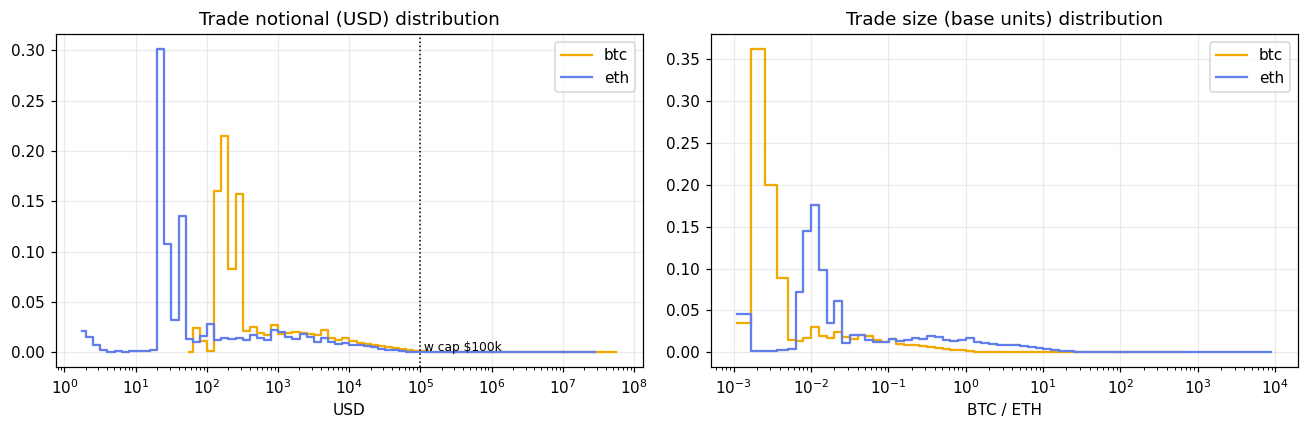

Trade quantiles:
               btc                eth         
          notional amount    notional   amount
q                                             
0.0100      67.134  0.001       1.925    0.001
0.1000     135.337  0.002      20.641    0.007
0.2500     175.369  0.002      22.490    0.009
0.5000     255.005  0.003      40.231    0.014
0.7500     932.041  0.011     311.523    0.120
0.9000    5228.200  0.067    2761.813    1.038
0.9900   51023.511  0.620   27283.553   10.302
0.9990  154125.000  1.866   88812.631   31.673
0.9999  491787.516  6.026  331353.613  124.830


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for sym in SYMS:
    h = pl.read_parquet(ART/f"trades_notional_hist_{sym}.parquet").sort("b")
    centers = np.sqrt(h["bin_lo"]*h["bin_hi"]); frac = h["count"]/h["count"].sum()
    axes[0].step(centers, frac, where="mid", color=COL[sym], label=f"{sym}")
    ha = pl.read_parquet(ART/f"trades_amount_hist_{sym}.parquet").sort("b")
    ca = np.sqrt(ha["bin_lo"]*ha["bin_hi"]); fa = ha["count"]/ha["count"].sum()
    axes[1].step(ca, fa, where="mid", color=COL[sym], label=f"{sym}")
axes[0].set_xscale("log"); axes[0].set_title("Trade notional (USD) distribution"); axes[0].set_xlabel("USD")
axes[0].legend(); axes[0].axvline(1e5, color="k", ls=":", lw=1); axes[0].text(1e5,0.001," w cap $100k",fontsize=8)
axes[1].set_xscale("log"); axes[1].set_title("Trade size (base units) distribution"); axes[1].set_xlabel("BTC / ETH")
axes[1].legend()
plt.tight_layout(); plt.show()

q = pd.concat({sym: pl.read_parquet(ART/f"trades_quantiles_{sym}.parquet").to_pandas().set_index("q")[["notional","amount"]]
               for sym in SYMS}, axis=1)
print("Trade quantiles:"); print(q.round(3).to_string())

* Both notional distributions are **strongly right-skewed on a log axis** — roughly log-normal core with a heavy upper tail. Median trade is **~$255 (BTC)** / **~$40 (ETH)**; p99 is ~$51 K / $27 K and p99.99 reaches ~$0.5 M / $0.33 M.
* ETH's distribution sits well to the **left** of BTC's: ETH trades are individually much smaller in USD (median $40 vs $255), consistent with ETH having 1.75× the count but a lower price. Lots of dust-sized prints.
* The dotted line at **$100 K** is the markout weight cap `w = min(notional, 100 K)`. Only the top ~0.5–1% of trades are clipped, but those clipped whales carry a large share of total turnover — relevant for the turnover constraint.

### 4.2 Liquidation size & notional — and how they compare to trades

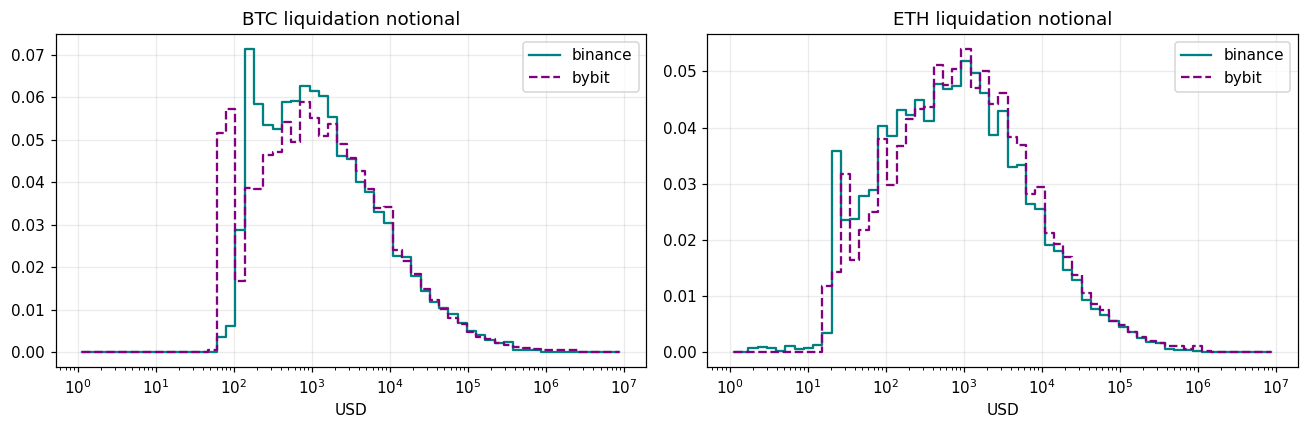

Liquidation notional summary (USD):
  binance btc: n=114,255  median=$   1,116  p99=$   163,353  max=$  15,054,962  total=$1,292M
  binance eth: n=131,769  median=$     728  p99=$   148,860  max=$  15,482,568  total=$1,309M
  bybit   btc: n=228,655  median=$   1,118  p99=$   200,303  max=$   3,439,243  total=$2,913M
  bybit   eth: n=160,214  median=$     912  p99=$   179,385  max=$   3,793,963  total=$1,646M


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, sym in zip(axes, SYMS):
    for exch, ls in [("binance","-"),("bybit","--")]:
        d = load_liq(exch, sym)
        notl = d["notional"].to_numpy(); notl = notl[notl>0]
        bins = np.logspace(0, 7, 60)
        h,_ = np.histogram(notl, bins=bins); h = h/h.sum()
        ax.step(np.sqrt(bins[:-1]*bins[1:]), h, where="mid", ls=ls,
                color="purple" if exch=="bybit" else "teal", label=f"{exch}")
    ax.set_xscale("log"); ax.set_title(f"{sym.upper()} liquidation notional"); ax.set_xlabel("USD"); ax.legend()
plt.tight_layout(); plt.show()

print("Liquidation notional summary (USD):")
for exch in ["binance","bybit"]:
    for sym in SYMS:
        n = load_liq(exch,sym)["notional"]
        print(f"  {exch:7s} {sym}: n={len(n):>7,}  median=${n.median():>8,.0f}  "
              f"p99=${n.quantile(0.99):>10,.0f}  max=${n.max():>12,.0f}  total=${n.sum()/1e6:,.0f}M")

* Individual liquidation prints are **small in the middle** (median ~$0.7–1.2 K, similar to a typical trade) but have an **even heavier tail** than trades — single liquidation orders run into the millions. These are per-order liquidation messages, not pre-aggregated.
* **Bybit liquidates far more total notional than Binance** (BTC $2.9 B vs $1.3 B; ETH $1.6 B vs $1.3 B) and its distribution is shifted slightly larger — Bybit's feed is both more frequent and chunkier. This is the first hint that the *cross-exchange* feed may carry more signal than Binance's own.

### 4.3 BBO spread distribution

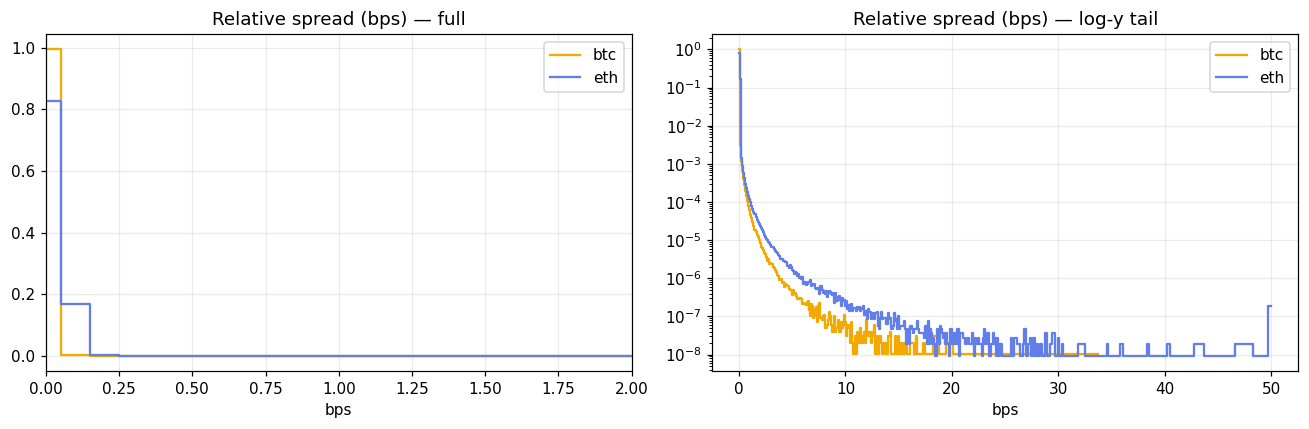

BBO quantiles:
          btc                           eth                      
      rel_bps bid_amount ask_amount rel_bps bid_amount ask_amount
q                                                                
0.010  0.0104      0.007      0.007  0.0298      0.082      0.096
0.100  0.0108      0.492      0.479  0.0311      5.708      5.728
0.250  0.0111      1.866      1.834  0.0322     23.949     23.222
0.500  0.0114      4.283      4.208  0.0339     59.606     58.998
0.750  0.0143      8.072      7.934  0.0480    113.932    112.498
0.900  0.0149     13.375     13.233  0.0511    185.261    182.710
0.990  0.0160     23.926     23.900  0.0549    369.805    367.386
0.999  0.4972     71.370     50.988  0.8583   1181.011   1248.846


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for sym in SYMS:
    sp = pl.read_parquet(ART/f"bbo_spread_hist_{sym}.parquet").sort("bps")
    frac = sp["count"]/sp["count"].sum()
    axes[0].step(sp["bps"], frac, where="mid", color=COL[sym], label=sym)
axes[0].set_title("Relative spread (bps) — full"); axes[0].set_xlabel("bps"); axes[0].set_xlim(0,2); axes[0].legend()
# zoom log-y to show tail
for sym in SYMS:
    sp = pl.read_parquet(ART/f"bbo_spread_hist_{sym}.parquet").sort("bps")
    frac = sp["count"]/sp["count"].sum()
    axes[1].step(sp["bps"], frac, where="mid", color=COL[sym], label=sym)
axes[1].set_yscale("log"); axes[1].set_title("Relative spread (bps) — log-y tail"); axes[1].set_xlabel("bps"); axes[1].legend()
plt.tight_layout(); plt.show()

qs = pd.concat({sym: pl.read_parquet(ART/f"bbo_quantiles_{sym}.parquet").to_pandas().set_index("q")[["rel_bps","bid_amount","ask_amount"]]
                for sym in SYMS}, axis=1)
print("BBO quantiles:"); print(qs.round(4).to_string())

* Spreads are **astonishingly tight**: BTC sits at **~0.011 bps median** (1 tick = \$0.10 on a ~\$80 K price) the vast majority of the time; ETH **~0.034 bps** (1 tick = \$0.01). The spread is essentially always 1 tick, widening only in the tail during stress (p99.9 jumps to ~0.5 / 0.86 bps).
* **Implication for the signal:** the +0.5 bps maker rebate is *huge* relative to the spread. Maker PnL will be dominated by the markout term (where the mid drifts after the fill), not by the half-spread — which is exactly why a liquidation-reversion signal can matter.
* Top-of-book depth: median ~4 BTC / ~60 ETH resting at the touch.

### 4.4 Side balance — trades vs liquidations

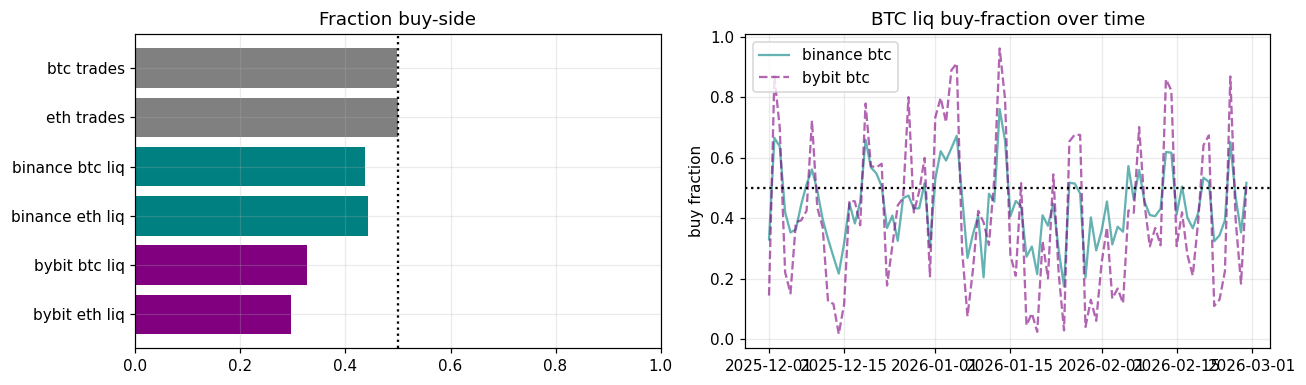

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
# trades buy fraction (overall + over time)
tr_rows=[]
for sym in SYMS:
    st = pl.read_parquet(ART/f"trades_stats_{sym}.parquet")
    tr_rows.append((f"{sym} trades", st["buy_n"][0]/st["count"][0]))
for exch in ["binance","bybit"]:
    for sym in SYMS:
        d = load_liq(exch,sym)
        tr_rows.append((f"{exch} {sym} liq", (d["side"]=="buy").mean()))
labels=[r[0] for r in tr_rows]; vals=[r[1] for r in tr_rows]
colors=["gray","gray"]+["teal","teal","purple","purple"]
axes[0].barh(labels, vals, color=colors); axes[0].axvline(0.5, color="k", ls=":")
axes[0].set_xlim(0,1); axes[0].set_title("Fraction buy-side")
axes[0].invert_yaxis()
# buy-fraction of liquidations over time (monthly) to show regime
for exch,ls in [("binance","-"),("bybit","--")]:
    d = load_liq(exch,"btc").with_columns(day=(pl.col("timestamp")//(86400*US)))
    g = d.group_by("day").agg(bf=(pl.col("side")=="buy").mean()).sort("day")
    axes[1].plot(min_to_dt(g["day"]*1440), g["bf"].to_numpy(), ls, color="purple" if exch=="bybit" else "teal",
                 alpha=0.6, label=f"{exch} btc")
axes[1].axhline(0.5, color="k", ls=":"); axes[1].set_title("BTC liq buy-fraction over time")
axes[1].set_ylabel("buy fraction"); axes[1].legend()
plt.tight_layout(); plt.show()

* **Trades are ~50/50** taker buy/sell (BTC 49.85%, ETH 49.93%) — expected for a matched tape; no directional bias to exploit in raw flow.
* **Liquidations are skewed to the sell side** (long liquidations): Binance ~44% buy, **Bybit only ~30–33% buy**. Bybit is markedly more long-liquidation-heavy. The right panel shows the buy-fraction swinging with the market — it spikes up on rally days (short squeezes) and collapses on sell-offs — i.e. liquidation side is itself a regime indicator.

## 5. The conventions that bite

`description.md` flags three easy-to-misread things. We verify each on concrete examples.

### 5.1 Timestamp units = microseconds since UNIX epoch (UTC)

In [11]:
raw = pl.read_parquet(RAW[("trades","btc")], n_rows=1)["timestamp"][0]
print("first BTC trade raw timestamp:", raw)
for unit, div in [("seconds",1), ("milliseconds",1e3), ("microseconds",1e6), ("nanoseconds",1e9)]:
    try:
        dt = datetime.fromtimestamp(raw/div, tz=timezone.utc)
        print(f"  if {unit:12s}: {dt}")
    except (OverflowError, OSError, ValueError) as e:
        print(f"  if {unit:12s}: out of range ({e})")
print("\n=> Only 'microseconds' lands in 2025-12; ms -> year ~57000, ns -> 1970. Confirmed: int64 microseconds UTC.")

first BTC trade raw timestamp: 1764547200047000
  if seconds     : out of range (year 55918244 is out of range)
  if milliseconds: out of range (year 57886 is out of range)
  if microseconds: 2025-12-01 00:00:00.047000+00:00
  if nanoseconds : 1970-01-21 10:09:07.200047+00:00

=> Only 'microseconds' lands in 2025-12; ms -> year ~57000, ns -> 1970. Confirmed: int64 microseconds UTC.


**Confirmed.** Dividing by 1e6 gives 2025-12-01 00:00:00.047 UTC; any other unit is absurd. Throughout, `timestamp / 1e6` = epoch seconds.

### 5.2 `side` means different things in `trades` vs `liquidations`

In **trades** `side` is the **taker** side: `buy` ⇒ taker lifted the ask (maker sold). We verify by comparing
each sampled trade's price to the prevailing Binance mid (forward-filled from BBO at the trade time).

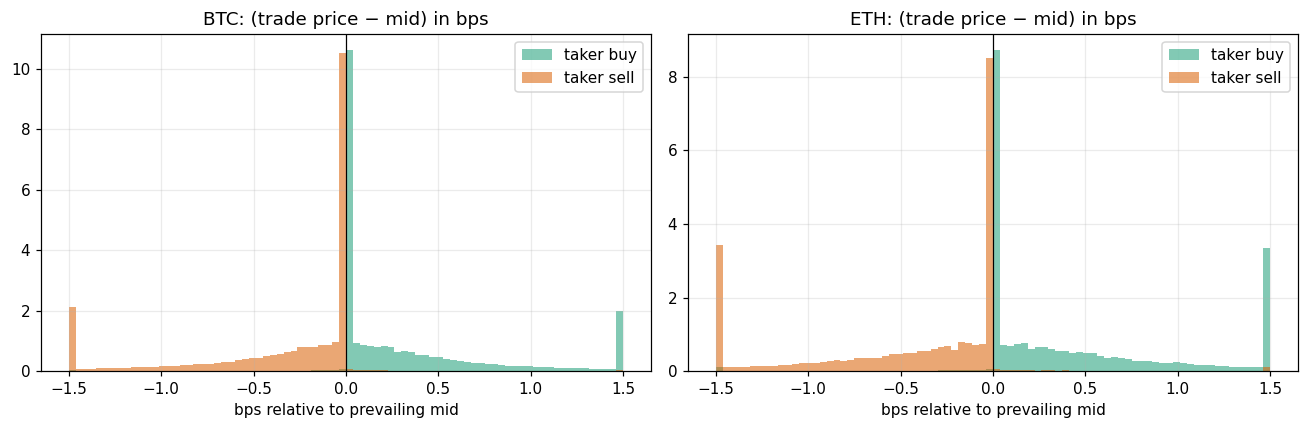

btc: taker-buy priced at/above mid: 98.1%   taker-sell at/below mid: 98.1%
eth: taker-buy priced at/above mid: 97.5%   taker-sell at/below mid: 97.5%


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, sym in zip(axes, SYMS):
    ti = pl.read_parquet(ART/f"trade_impact_{sym}.parquet")
    ti = ti.filter(pl.col("m_pre").is_not_nan())
    for sd in ["buy","sell"]:
        v = ti.filter(pl.col("side")==sd)["px_vs_mid_bps"].to_numpy()
        v = v[np.isfinite(v)]
        # px_vs_mid is sign-flipped by side in the artifact (signed by taker dir); undo for raw view
        ax.hist(np.clip(v if sd=="buy" else -v, -1.5, 1.5), bins=80, alpha=0.55,
                color=SIDE_COL[sd], label=f"taker {sd}", density=True)
    ax.axvline(0, color="k", lw=0.8); ax.set_title(f"{sym.upper()}: (trade price − mid) in bps")
    ax.set_xlabel("bps relative to prevailing mid"); ax.legend()
plt.tight_layout(); plt.show()

for sym in SYMS:
    ti = pl.read_parquet(ART/f"trade_impact_{sym}.parquet").filter(pl.col("m_pre").is_not_nan())
    buy = ti.filter(pl.col("side")=="buy"); sell = ti.filter(pl.col("side")=="sell")
    # px_vs_mid_bps = sign*(price-mid)/mid*1e4 ; for buy sign=+1, for sell sign=-1
    fb = (buy["px_vs_mid_bps"]>=0).mean(); fs = (sell["px_vs_mid_bps"]>=0).mean()
    print(f"{sym}: taker-buy priced at/above mid: {fb:.1%}   taker-sell at/below mid: {fs:.1%}")

**Confirmed.** Taker-buy trades print **at or above** the mid ~98% of the time (and taker-sell at/below), with the buy distribution sitting on the positive side and sell on the negative. The ~2% on the "wrong" side are trades where the mid moved between the last BBO tick and the trade (BBO is throttled, so the forward-filled mid is slightly stale). So in the markout formula, `s_i = +1` for taker-buy = maker-sell is correct, and a maker who *sold* profits when the mid later falls.

In **liquidations**, `side` is the **liquidation order** side: `buy` ⇒ a short is force-closed by buying ⇒ upward pressure. We verify this via the price-response profiles in §6.2, where buy-liqs sit at a local top of a *rising* move and sell-liqs at a local bottom of a *falling* one — exactly the implied pressure direction.

### 5.3 Bybit cross-exchange +200 ms availability

Bybit and Binance are different venues; we treat Bybit events as available only **200 ms after** their timestamp.
Two questions: (a) are the two clocks even aligned, and (b) how much does the 200 ms handicap actually cost?

In [13]:
# (a) Is the Bybit clock aligned with Binance? Look at where the Binance-mid move
#     inflects relative to the Bybit liquidation timestamp (offset 0 in the profile).
prof = pl.read_parquet(ART/"liq_profile_bybit_eth.parquet")
piv = prof.filter(pl.col("offset_s").abs()<=1).pivot(index="offset_s", on="side", values="mean_bps").sort("offset_s")
print("Bybit ETH: Binance-mid move (bps) right around the Bybit liq timestamp (offset 0):")
print(piv.to_pandas().set_index("offset_s").round(3).to_string())

# (b) cost of waiting 200ms = how much of the eventual move happens in [0, +0.2s]
for sym in SYMS:
    pr = pl.read_parquet(ART/f"liq_profile_bybit_{sym}.parquet")
    def at(o,sd):
        r=pr.filter((pl.col("offset_s")==o)&(pl.col("side")==sd))["mean_bps"]
        return float(r[0]) if len(r) else np.nan
    for sd in ["buy","sell"]:
        m02, m300 = at(0.2,sd), at(300.0,sd)
        print(f"{sym} {sd}-liq: move by +0.2s = {m02:+.3f} bps,  by +300s = {m300:+.3f} bps  "
              f"=> 200ms captures {100*m02/m300 if m300 else 0:.1f}% of the 5-min move")

Bybit ETH: Binance-mid move (bps) right around the Bybit liq timestamp (offset 0):
            buy   sell
offset_s              
-1.0     -4.143  4.684
-0.5     -1.093  1.389
-0.2     -0.251  0.390
-0.1     -0.102  0.172
 0.0      0.000  0.000
 0.1      0.102 -0.155
 0.2      0.182 -0.278
 0.5      0.339 -0.576
 1.0      0.433 -0.901
btc buy-liq: move by +0.2s = +0.114 bps,  by +300s = -3.368 bps  => 200ms captures -3.4% of the 5-min move
btc sell-liq: move by +0.2s = -0.144 bps,  by +300s = +6.216 bps  => 200ms captures -2.3% of the 5-min move
eth buy-liq: move by +0.2s = +0.182 bps,  by +300s = -5.274 bps  => 200ms captures -3.5% of the 5-min move
eth sell-liq: move by +0.2s = -0.278 bps,  by +300s = +14.876 bps  => 200ms captures -1.9% of the 5-min move


* **(a) The clocks are effectively aligned.** The Binance-mid path is essentially flat at offset 0 and symmetric in the ±0.1–0.2 s neighbourhood of the Bybit timestamp — there is no large systematic lead/lag, so the +200 ms is a *network/availability* handicap, not a clock-skew correction. (If Bybit timestamps were, say, 1 s behind Binance, the inflection would be visibly off-centre.)
* **(b) The handicap is nearly free for this signal.** Only a tiny fraction of the eventual multi-minute move occurs in the first 200 ms; the large reversion (§6.2) unfolds over tens of seconds to minutes. So shifting Bybit by +200 ms barely dents the usable signal — which is *why* Bybit data is worth keeping despite the delay.
* **Caveat that bites:** Bybit liquidations are **not strictly time-sorted** (0.03% of rows step backwards, by up to ~22 ms) and have thousands of **same-microsecond collisions** (cascade bursts). Always `sort` Bybit by timestamp (and add the +200 ms) before any as-of join. See §7.

## 6. Cross-source relationships

### 6.1 Order book around a trade — price impact

For a sample of trades we forward-fill the Binance mid just before the trade and at small offsets after it,
then sign the mid change by the taker direction. This is the average *impact* of a taker trade, split by trade size.

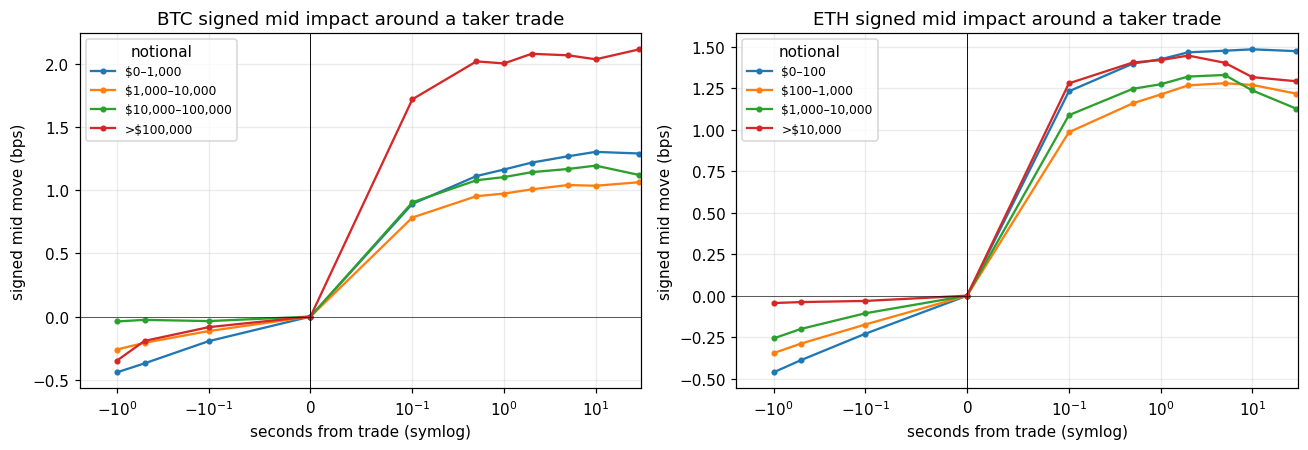

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
size_q = {"btc":[0,1e3,1e4,1e5,1e12], "eth":[0,1e2,1e3,1e4,1e12]}
for ax, sym in zip(axes, SYMS):
    ti = pl.read_parquet(ART/f"trade_impact_{sym}.parquet").filter(pl.col("m_pre").is_not_nan())
    impc = [c for c in ti.columns if c.startswith("imp_")]
    offs = sorted(float(c[4:]) for c in impc)
    edges = size_q[sym]
    for i in range(len(edges)-1):
        sub = ti.filter((pl.col("notional")>=edges[i])&(pl.col("notional")<edges[i+1]))
        if sub.height < 50: continue
        ys = [float(np.nanmean(sub[f"imp_{o}"].to_numpy())) for o in offs]
        lbl = f"${edges[i]:,.0f}–{edges[i+1]:,.0f}" if edges[i+1]<1e12 else f">${edges[i]:,.0f}"
        ax.plot(offs, ys, marker="o", ms=3, label=lbl)
    ax.axvline(0, color="k", lw=0.6); ax.axhline(0, color="k", lw=0.4)
    ax.set_xscale("symlog", linthresh=0.1); ax.set_title(f"{sym.upper()} signed mid impact around a taker trade")
    ax.set_xlabel("seconds from trade (symlog)"); ax.set_ylabel("signed mid move (bps)"); ax.legend(fontsize=8, title="notional")
plt.tight_layout(); plt.show()

* Taker trades have **monotone price impact in their own direction**, scaling with size: a small trade nudges the mid a fraction of a bp; the largest bucket (>\$100 K) moves it several bps and the move **persists** over the next seconds rather than fully reverting. The pre-trade lines tilt the right way too (mid drifts toward the trade just before it prints — order-book pressure).
* Because the spread is ~1 tick, even sub-bp impact is meaningful relative to the half-spread. For a maker, getting run over by a string of same-side takers (informed flow) is the adverse-selection cost the signal must avoid.

### 6.2 Order book around a liquidation — the headline relationship

Average Binance-mid path around each liquidation (event at offset 0, **unsigned** bps relative to the mid at the event),
split by liquidation side and by exchange. Buy-liq = upward pressure, sell-liq = downward pressure.

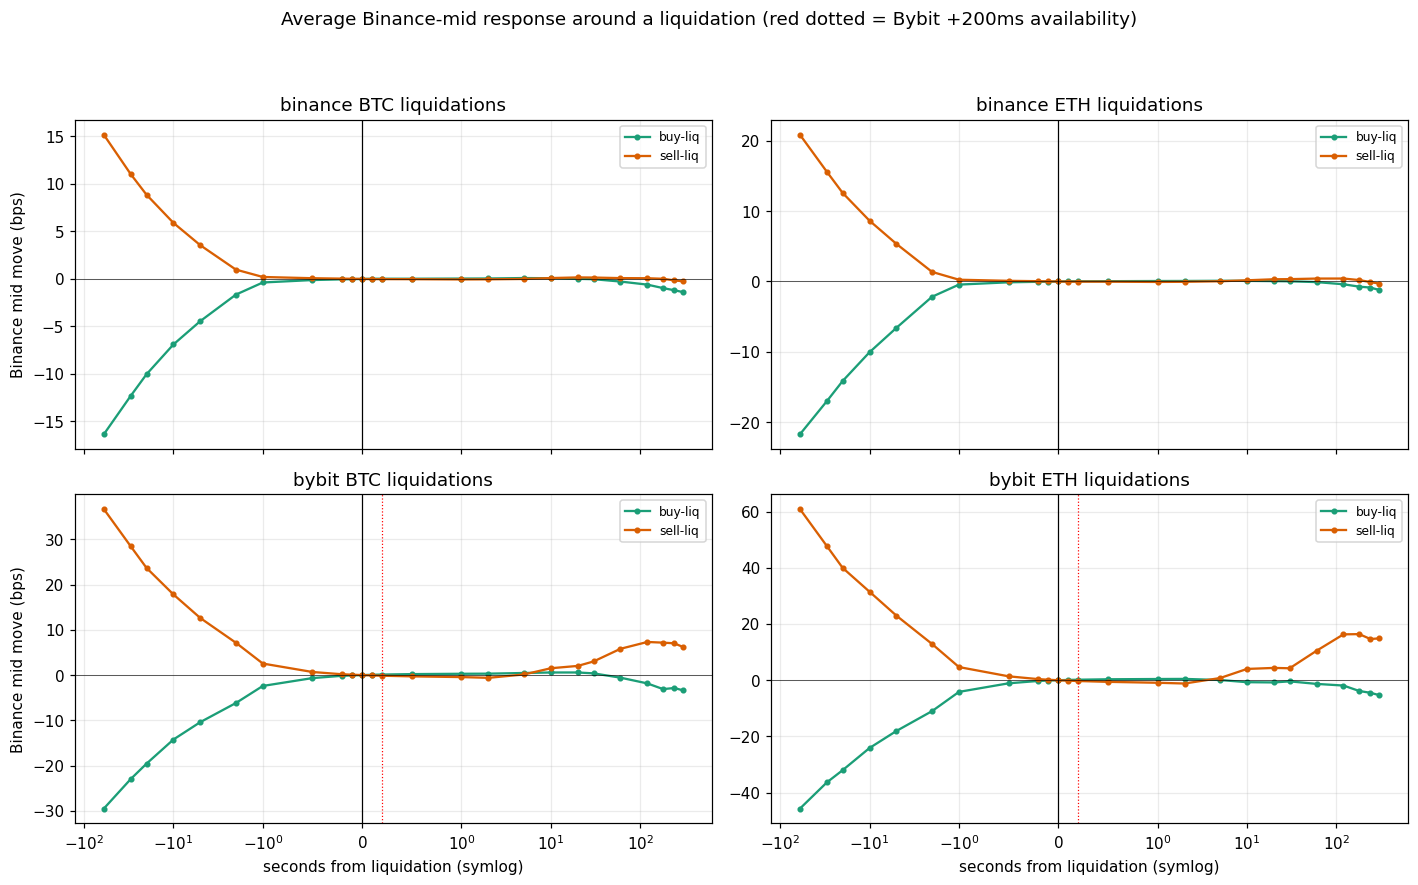

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)
for j, sym in enumerate(SYMS):
    for i, exch in enumerate(["binance","bybit"]):
        ax = axes[i][j]
        pr = pl.read_parquet(ART/f"liq_profile_{exch}_{sym}.parquet")
        for sd in ["buy","sell"]:
            s = pr.filter(pl.col("side")==sd).sort("offset_s")
            ax.plot(s["offset_s"], s["mean_bps"], marker="o", ms=3, color=SIDE_COL[sd], label=f"{sd}-liq")
        ax.axvline(0, color="k", lw=0.8)
        if exch=="bybit": ax.axvline(0.2, color="red", lw=0.8, ls=":")  # +200ms availability
        ax.axhline(0, color="k", lw=0.4)
        ax.set_xscale("symlog", linthresh=1)
        ax.set_title(f"{exch} {sym.upper()} liquidations"); ax.legend(fontsize=8)
        if i==1: ax.set_xlabel("seconds from liquidation (symlog)")
        if j==0: ax.set_ylabel("Binance mid move (bps)")
fig.suptitle("Average Binance-mid response around a liquidation (red dotted = Bybit +200ms availability)", y=1.0)
plt.tight_layout(rect=[0,0,1,0.96]); plt.show()

In [16]:
# signed, notional-weighted markout table (the maker-relevant view), nan-safe
print("Signed liquidation markout in bps  (+ = mid continued in the liq's pressure direction;")
print(" negative = REVERSION against the liquidation). Weight = min(notional, $100k).\n")
rows=[]
for exch in ["binance","bybit"]:
    for sym in SYMS:
        d = pl.read_parquet(ART/f"liq_markout_{exch}_{sym}.parquet").with_columns(
            w=pl.min_horizontal(pl.col("notional"), pl.lit(100000.0)))
        for sd in ["buy","sell","ALL"]:
            dd = d if sd=="ALL" else d.filter(pl.col("side")==sd)
            rec=dict(exch=exch,sym=sym,side=sd,n=dd.height)
            for h in ["30","120","300"]:
                x = dd.filter(pl.col(f"ret_{h}").is_not_nan())
                rec[f"mk_{h}s"]=round(float((x[f"ret_{h}"]*x["w"]).sum()/x["w"].sum()),2)
            rows.append(rec)
print(pd.DataFrame(rows).to_string(index=False))

Signed liquidation markout in bps  (+ = mid continued in the liq's pressure direction;
 negative = REVERSION against the liquidation). Weight = min(notional, $100k).

   exch sym side      n  mk_30s  mk_120s  mk_300s
binance btc  buy  50046   -0.09    -0.20    -1.41
binance btc sell  64209    0.33     0.53     0.74
binance btc  ALL 114255    0.14     0.19    -0.26
binance eth  buy  58295    0.38    -0.29    -1.23
binance eth sell  73474   -0.46    -0.58     0.47
binance eth  ALL 131769   -0.07    -0.44    -0.31
  bybit btc  buy  74857    0.50    -2.67    -4.32
  bybit btc sell 153798   -3.52    -9.26    -8.18
  bybit btc  ALL 228655   -2.15    -7.02    -6.87
  bybit eth  buy  47547   -0.18    -1.82    -5.77
  bybit eth sell 112667   -4.79   -18.15   -16.12
  bybit eth  ALL 160214   -3.35   -13.04   -12.88


**This is the core finding.** Around every liquidation the Binance mid traces the same shape:

1. **Run-in:** the mid moves *into* the liquidation for the prior 10–60 s (price rising before a buy-liq = short squeeze; falling before a sell-liq = long flush). Liquidations mark the **local extreme** of a fast move.
2. **Tiny continuation:** for ~1–2 s after the print the mid nudges a fraction of a bp further in the liquidation's direction (the forced order's own impact).
3. **Reversion:** then the mid **reverses** over tens of seconds to minutes. The signed, notional-weighted markout is **negative at 120–300 s** for almost every cell — the market gives back the liquidation move.

Two asymmetries matter for the signal:
* **Bybit ≫ Binance.** Bybit's own-liquidation reversion is an order of magnitude larger (ETH sell-liq ≈ **+15 bps** reversion at 300 s vs Binance's ≈ +0.4 bps). A *cross-exchange* liquidation is a much stronger predictor of a Binance mean-reversion than Binance's own liquidation feed — and it survives the +200 ms handicap. This is the heart of why the task hands us Bybit data.
* **ETH ≫ BTC**, and **sell-liqs ≫ buy-liqs** (in this falling-market sample) — the biggest reversions come from long-liquidation cascades in ETH.

For a maker: if you *bought* (taker-sell hit you) right as a sell-liquidation cascade prints, the subsequent up-reversion is in your favour; the danger is being filled on the wrong side just before the continuation. The signal's job is to separate these.

### 6.3 Cross-exchange alignment — do Bybit and Binance liquidations line up?

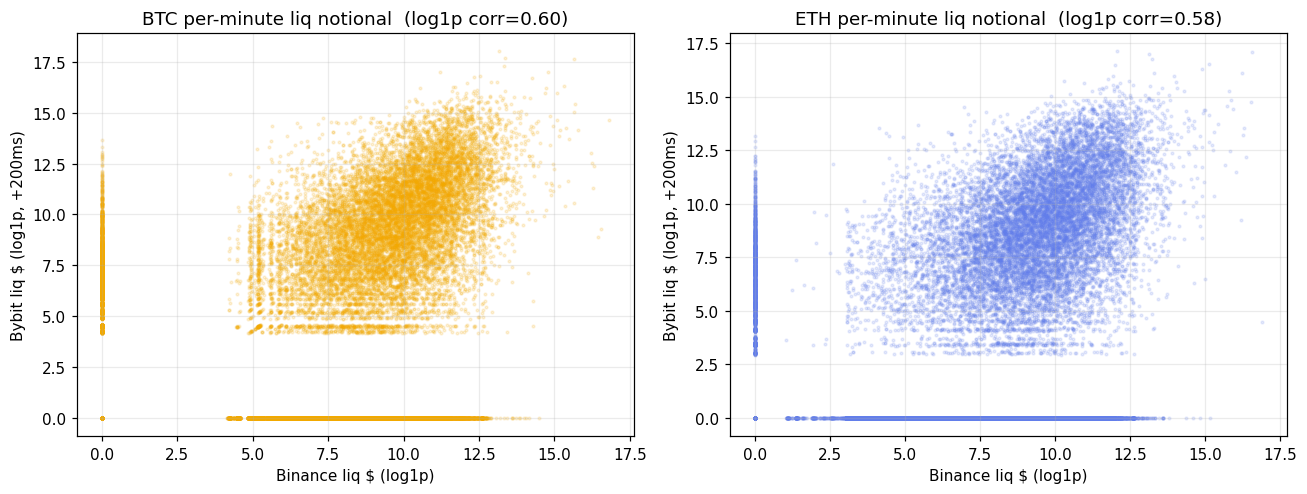

In [17]:
MIN=60_000_000
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
for ax, sym in zip(axes, SYMS):
    b = load_liq("binance",sym).with_columns(m=(pl.col("timestamp")//MIN))
    y = load_liq("bybit",sym).with_columns(m=((pl.col("timestamp")+200_000)//MIN))  # +200ms shift
    bm = b.group_by("m").agg(bn=pl.col("notional").sum())
    ym = y.group_by("m").agg(yn=pl.col("notional").sum())
    j = bm.join(ym, on="m", how="full", coalesce=True).fill_null(0.0)
    grid = pl.DataFrame({"m": np.arange(j["m"].min(), j["m"].max()+1)})
    j = grid.join(j, on="m", how="left").fill_null(0.0)
    x=np.log1p(j["bn"].to_numpy()); yv=np.log1p(j["yn"].to_numpy())
    ax.scatter(x, yv, s=3, alpha=0.15, color=COL[sym])
    c=np.corrcoef(x,yv)[0,1]
    ax.set_title(f"{sym.upper()} per-minute liq notional  (log1p corr={c:.2f})")
    ax.set_xlabel("Binance liq $ (log1p)"); ax.set_ylabel("Bybit liq $ (log1p, +200ms)")
plt.tight_layout(); plt.show()

* Liquidation activity is **co-timed but far from identical** across venues: log-space per-minute correlation ≈ **0.6** (BTC) / **0.58** (ETH). Big cascade minutes light up both exchanges (the diagonal cloud), but each venue also has plenty of minutes where only one fires.
* Combined with §6.2, this says the two feeds carry **overlapping but non-redundant** information. Bybit's larger, more frequent liquidations plus the much stronger reversion signal make it the more valuable feed — even though we see it 200 ms late.

## 7. Anomalies & things that look odd

A consolidated list of the quirks found while exploring — each verified above.

In [18]:
print("1. Bybit liquidations are NOT strictly time-sorted, and have same-microsecond collisions:")
for sym in SYMS:
    d = pl.read_parquet(RAW[("liq_bybit",sym)])
    diff = d["timestamp"].diff().drop_nulls()
    back = diff.filter(diff<0)
    coll = d.height - d.select("timestamp").unique().height
    print(f"   bybit {sym}: {back.len()} backward steps (max {-back.min()/1000:.0f} ms), "
          f"{coll:,} ts-collisions, {d.height-d.unique().height} exact dup rows")
print("   Binance liquidations: strictly monotonic, 0 collisions, 0 dups (checked).")

print("\n2. BBO has a handful of multi-minute gaps, shared across BTC & ETH (collector/venue outages):")
for sym in SYMS:
    m = pl.read_parquet(ART/f"bbo_minute_{sym}.parquet")
    full=np.arange(m["m"].min(),m["m"].max()+1); miss=sorted(set(full)-set(m["m"].to_list()))
    print(f"   {sym}: {len(miss)} missing minutes")

print("\n3. Trade burstiness: busiest minute is 74x (BTC) / 87x (ETH) the median — pure volatility clustering.")

print("\n4. Markout boundary: 1-2 liquidations in the final 300 s of the sample have t+τ beyond the last")
print("   BBO tick and are correctly excluded (NaN) per the description's rule.")

print("\n5. Clean where it counts: 0 crossed/locked books, 0 non-positive spreads, 0 zero-size trades,")
print("   0 null/NaN prices across all 207M BBO rows and 1.1B trades.")

1. Bybit liquidations are NOT strictly time-sorted, and have same-microsecond collisions:
   bybit btc: 63 backward steps (max 22 ms), 5,094 ts-collisions, 1 exact dup rows
   bybit eth: 46 backward steps (max 16 ms), 2,664 ts-collisions, 2 exact dup rows
   Binance liquidations: strictly monotonic, 0 collisions, 0 dups (checked).

2. BBO has a handful of multi-minute gaps, shared across BTC & ETH (collector/venue outages):
   btc: 6 missing minutes
   eth: 9 missing minutes

3. Trade burstiness: busiest minute is 74x (BTC) / 87x (ETH) the median — pure volatility clustering.

4. Markout boundary: 1-2 liquidations in the final 300 s of the sample have t+τ beyond the last
   BBO tick and are correctly excluded (NaN) per the description's rule.

5. Clean where it counts: 0 crossed/locked books, 0 non-positive spreads, 0 zero-size trades,
   0 null/NaN prices across all 207M BBO rows and 1.1B trades.


None of these are corrupting; they are the kind of thing that silently breaks a pipeline if ignored:
* **Sort Bybit** (and apply +200 ms) before joining — its rows are mildly out of order.
* **Forward-fill across the BBO gaps** is fine but be aware a few `t+τ` lookups span a multi-minute hole (esp. 2026-02-26 13:30–13:32).
* **Drop trades whose `t+τ` exceeds the BBO end** (handful at the sample tail), as the markout spec says.

## 8. Summary of findings

**Shape & integrity**
* 90 days (2025-12-01 → 2026-02-28 UTC), 8 tables, identical span. ≈1.1 B trades, ≈207 M BBO ticks, ~0.63 M liquidations total.
* Data is clean: no crossed books, zero/negative prices, or NaNs. BBO ~99.99% complete (a few shared multi-minute outages). Trades never stop.
* **Timestamps are int64 microseconds UTC** — verified by hand.

**Distributions**
* Trade & liquidation notionals are **heavy-tailed / log-normal-ish**; BTC median trade ~$255, ETH ~$40. The `min(notional, $100K)` weight clips only the top ~1%.
* **Spreads are ~1 tick almost always** (BTC ~0.011 bps, ETH ~0.034 bps median) → the +0.5 bps rebate and the markout dominate maker PnL, not the spread.
* **Trade flow is ~50/50**; **liquidations skew sell-side** (Bybit most of all), tracking the BTC drawdown.

**The conventions that bite (all verified)**
* `side` in trades = taker side (buy prints ≥ mid 98% of the time). `side` in liquidations = liq-order side, and the price-response confirms buy=upward / sell=downward pressure.
* The Bybit +200 ms is an availability handicap, **not** a clock offset (clocks are aligned), and it costs almost none of the usable signal. But Bybit rows are **not sorted** and have microsecond collisions — sort first.

**Cross-source relationships (the signal thesis)**
* A liquidation marks the **local extreme** of a fast move, shows a tiny same-direction continuation (~1–2 s), then a **multi-minute reversion** of the Binance mid.
* **Bybit liquidations predict that reversion ~10× more strongly than Binance's own** (e.g. ETH sell-liqs ≈ +15 bps at 300 s), and the effect survives the 200 ms delay — the single most promising relationship in the data.
* Taker trades carry **persistent, size-scaling impact** (adverse selection) — the other side of what a maker filter must manage.

**Where I'd look next** (for the eventual filter, beyond this week)
* Build the actual markout/PnL pipeline and confirm that filtering trades near Bybit (and Binance) liquidation cascades — on the side that faces the post-liquidation reversion — improves `Score(τ)` while respecting the $500K/day kept-turnover constraint.
* Study the run-in vs reversion split by liquidation size/cluster intensity; the heavy tail suggests a few large cascades drive most of the signal.